In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [4]:
# CNN Input Shape
# PyTorch CNN expects:
# batch_size x channels x height x width

x = torch.randn(8, 3, 32, 32)

print("CNN input shape:", x.shape)

CNN input shape: torch.Size([8, 3, 32, 32])


In [5]:
# conv2d Layer

conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

x = torch.randn(8, 3, 32, 32)

output = conv(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([8, 3, 32, 32])
Output shape: torch.Size([8, 16, 32, 32])


In [6]:
# Max Pooling

pool = nn.MaxPool2d(kernel_size=2, stride=2)

x = torch.randn(8, 16, 32, 32)

output = pool(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([8, 16, 32, 32])
Output shape: torch.Size([8, 16, 16, 16])


In [18]:
# CNN Model
# Example for 32 x 32 RGB images

class SimpleCNN(nn.Module):

  def __init__(self, num_classes = 10):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

    self.pool = nn.MaxPool2d(2,2)

    self.fc1 = nn.Linear(32 * 8 * 8, 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):

    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool(x)

    #print("After conv1 + pool:", x.shape)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool(x)

    #print("After conv2 + pool:", x.shape)

    x = x.view(x.size(0), -1)

    #print("After flatten:", x.shape)

    x = self.fc1(x)
    x = F.relu(x)

    x = self.fc2(x)

    return x

model = SimpleCNN(num_classes=10)

dummy_input = torch.randn(4, 1, 32, 32)

output = model(dummy_input)

print("Final output shape:", output.shape)

Final output shape: torch.Size([4, 10])


In [8]:
from torch.utils.data import DataLoader
# MNIST Dataset

import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train = True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

classes = train_dataset.classes

print("Classes:", classes)
print("Number of training images:", len(train_dataset))
print("Number of test images:", len(test_dataset))




100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.46MB/s]

Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Number of training images: 60000
Number of test images: 10000


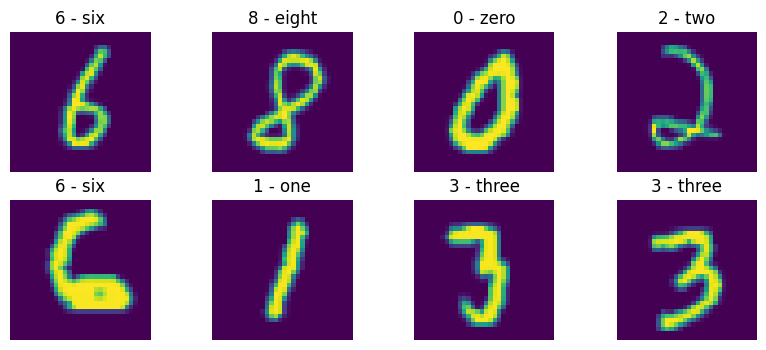

In [9]:
# Visualize Some Images

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,4))

for i in range(8):
  image = images[i]

  # Convert CHW to HWC for matplotlib
  image = image.permute(1, 2, 0)

  plt.subplot(2, 4, i+1)
  plt.imshow(image)
  plt.title(classes[labels[i]])
  plt.axis("off")

plt.show()

In [19]:
# Train CNN on MNIST
device = ("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
  model.train()

  running_loss = 0
  correct = 0
  total = 0

  for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    logits = model(images)
    loss = criterion(logits, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    predictions = torch.argmax(logits, dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

  train_acc = correct / total

  print(f"Epoch {epoch+1}, Loss:{running_loss}, Train Accuracy:{train_acc}")

Epoch 1, Loss:197.8813279243186, Train Accuracy:0.9378833333333333
Epoch 2, Loss:54.628470175899565, Train Accuracy:0.9816333333333334
Epoch 3, Loss:38.438727843225934, Train Accuracy:0.9873833333333333
Epoch 4, Loss:27.586038882029243, Train Accuracy:0.9908166666666667
Epoch 5, Loss:23.024396564578637, Train Accuracy:0.9919833333333333


In [21]:
# Evaluate CNN

model.eval()

correct = 0
total = 0

with torch.no_grad():

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    logits = model(images)

    predictions = torch.argmax(logits, dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

test_acc = correct / total

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9879


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Install Git if not already available
!apt-get install git

# Configure your GitHub identity (replace with your details)
!git config --global user.email "kottanapradeep123@gmail.com"
!git config --global user.name "pradeep-kottana"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [7]:
!git clone https://github.com/pradeep-kottana/Mathematical-foundations-to-Generative-AI.git
%cd Mathematical-foundations-to-Generative-AI


Cloning into 'Mathematical-foundations-to-Generative-AI'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 5.97 KiB | 5.97 MiB/s, done.
/content/Mathematical-foundations-to-Generative-AI


In [8]:
%cd Gen-AI-files

/content/Mathematical-foundations-to-Generative-AI/Gen-AI-files
